# Two-regime HMM: volatility-and-mean initialization sweep

Fit a two-state Gaussian HMM on daily S&P 500 **price-index log returns**. Train on exactly ten years (1990–1999) and evaluate 2000. The regime initialization **does not threshold the current return**. For each window in $[10,20,60]$ trading days, it uses the *prior* window's volatility and mean return to form a risk score. The current return is used only to estimate the Gaussian emission moments within the resulting groups.

The rolling features are only an **initialization aid**, not HMM observations: after initialization, Baum–Welch sees returns alone and is free to change emissions and transition probabilities. Consequently, different windows can converge to nearly identical fitted regimes. Inferred regimes are not observed market labels.

Window selection uses 1990–1997 for fitting and 1998–1999 for chronological validation. The chosen window is refit on 1990–1999. Year 2000 is held out for plots and diagnostics, never used to choose the window.

In [22]:
from pathlib import Path
import json
from math import erf
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / "src/flexible_emission_hmm").exists():
    project_root = project_root.parent
if not (project_root / "src/flexible_emission_hmm").exists():
    raise FileNotFoundError("Run from the project root or notebooks directory")
sys.path.insert(0, str(project_root / "src"))

from flexible_emission_hmm.emissions import GaussianEmission
from flexible_emission_hmm.feature import daily_log_return, rolling_mean_return, rolling_volatility
from flexible_emission_hmm.hmm import HMM
from flexible_emission_hmm.training import BaumWelchTrainer

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
OUTPUT_DIR = project_root / "data/artifacts/sp500_two_regime/vol_mean_sweep"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOWS = (10, 20, 60)
MAX_ITER, TOL, MIN_VARIANCE = 120, 1e-3, 1e-5

data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = daily_log_return(prices).dropna()
development = returns.loc["1990":"1997"]
validation = returns.loc["1998":"1999"]
training = returns.loc["1990":"1999"]
test = returns.loc["2000"]
if any(series.empty for series in (development, validation, training, test)):
    raise ValueError("A requested period is empty")
if len(training.index.year.unique()) != 10 or test.index.year.unique().tolist() != [2000]:
    raise ValueError("Expected ten training years and 2000 evaluation")
lagged_returns = returns.shift(1)
features = {
    window: pd.DataFrame({
        "volatility": rolling_volatility(lagged_returns, days=window),
        "mean": rolling_mean_return(lagged_returns, days=window),
    })
    for window in WINDOWS
}
for window in WINDOWS:
    if features[window].loc[training.index].isna().any().any():
        raise ValueError(f"Missing lagged features for {window}-day window")
print(f"Development: {len(development)} days; validation: {len(validation)} days")
print(f"Full training: {len(training)} days; held-out 2000: {len(test)} days")

Development: 2024 days; validation: 504 days
Full training: 2528 days; held-out 2000: 252 days


## Prespecified feature score and emission cut

For each fitting period and window $w$, rank the **lagged** rolling volatility and rolling mean among that period's days. Define

$$
s_t^{(w)}=\tfrac12\,\operatorname{rankpct}(\sigma_{t-1,w})
+\tfrac12\left[1-\operatorname{rankpct}(m_{t-1,w})\right].
$$

High prior volatility and a low prior mean both increase the score. Candidate cuts are score quantiles from 15% to 85%, with at least 15% of fitting days on either side. For each cut, estimate Gaussian mean and variance of the *current* return in the two feature-defined groups, then maximize the grouped-vs-single-Gaussian likelihood improvement

$$
G(c)=\tfrac12\left[n\log v_{\mathrm{all}}-n_0\log v_0-n_1\log v_1\right].
$$

This selects **initial** emission parameters, not true labels or a formal distribution test. The score, candidate cuts, and optimization criterion are the same for all three windows. All ranks, cuts, and standardization are recomputed using only the period available at that fitting stage.

In [23]:
class CutInitializedGaussian(GaussianEmission):
    def __init__(self, means, variances):
        super().__init__(n_states=2, min_variance=MIN_VARIANCE)
        self.seed_means = np.asarray(means, dtype=float).copy()
        self.seed_variances = np.asarray(variances, dtype=float).copy()

    def initialize(self, X):
        if X.shape[1] != 1:
            raise ValueError("This experiment requires one return feature")
        self.n_features = 1
        self.means = self.seed_means.reshape(2, 1).copy()
        self.covariances = self.seed_variances.reshape(2, 1, 1).copy()


def initialize_from_features(fit_returns, window):
    feature_frame = features[window].loc[fit_returns.index]
    score = (
        0.5 * feature_frame["volatility"].rank(pct=True)
        + 0.5 * (1 - feature_frame["mean"].rank(pct=True))
    )
    center = float(fit_returns.mean())
    scale = float(fit_returns.std(ddof=0))
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError("Fitting returns have no dispersion")
    standardized = ((fit_returns - center) / scale).to_numpy()
    candidates = np.unique(np.quantile(score.to_numpy(), np.linspace(0.15, 0.85, 71)))
    base_variance = max(float(np.var(standardized)), MIN_VARIANCE)
    rows = []
    for cut in candidates:
        low_mask = score.to_numpy() <= cut
        low, high = standardized[low_mask], standardized[~low_mask]
        if min(len(low), len(high)) < 0.15 * len(standardized):
            continue
        low_variance = max(float(np.var(low)), MIN_VARIANCE)
        high_variance = max(float(np.var(high)), MIN_VARIANCE)
        gain = 0.5 * (
            len(standardized) * np.log(base_variance)
            - len(low) * np.log(low_variance)
            - len(high) * np.log(high_variance)
        )
        rows.append({
            "window": window, "cut": float(cut), "gain_nats": float(gain),
            "low_days": len(low), "high_days": len(high),
            "low_mean_z": float(low.mean()), "high_mean_z": float(high.mean()),
            "low_variance_z": low_variance, "high_variance_z": high_variance,
        })
    candidate_table = pd.DataFrame(rows)
    if candidate_table.empty:
        raise ValueError(f"No admissible cutoff for {window}-day features")
    selected = candidate_table.loc[candidate_table["gain_nats"].idxmax()]
    return {
        "center": center, "scale": scale, "standardized": standardized,
        "score": score, "candidates": candidate_table, "selected": selected,
        "hard_group": (score > selected["cut"]).astype(int),
    }


def fit_window(fit_returns, window):
    initialization = initialize_from_features(fit_returns, window)
    selected = initialization["selected"]
    emission = CutInitializedGaussian(
        [selected["low_mean_z"], selected["high_mean_z"]],
        [selected["low_variance_z"], selected["high_variance_z"]],
    )
    trainer = BaumWelchTrainer(max_iter=MAX_ITER, tol=TOL)
    model = HMM(emission, trainer=trainer).fit(initialization["standardized"].reshape(-1, 1))
    high_state = int(np.argmax(model.emission.covariances[:, 0, 0]))
    return {"window": window, "model": model, "trainer": trainer,
            "initialization": initialization, "high_state": high_state}


def forecast_period(fit_result, fit_returns, evaluation_returns):
    initialization = fit_result["initialization"]
    model = fit_result["model"]
    fit_z = ((fit_returns - initialization["center"]) / initialization["scale"]).to_numpy()
    evaluation_z = (
        (evaluation_returns - initialization["center"]) / initialization["scale"]
    ).to_numpy()
    _, fit_filtered, _ = model.filter(fit_z.reshape(-1, 1))
    prior = fit_filtered[-1] @ model.states.transitions
    predicted, filtered, log_density_z = model.filter(
        evaluation_z.reshape(-1, 1), initial_prior=prior
    )
    return {
        "fit_filtered": fit_filtered, "first_prior": prior,
        "predicted": predicted, "filtered": filtered,
        "log_density": log_density_z - np.log(initialization["scale"]),
    }

## Chronological validation sweep

Fit one model per window on 1990–1997. Score the sequential one-step predictive density over 1998–1999 using the final development filtered state as the initial prior. Choose the window with the **lowest validation mean negative log predictive density**; no 2000 values enter this selection. A lower score is better.

In [24]:
validation_results = {}
validation_rows = []
for window in WINDOWS:
    fitted = fit_window(development, window)
    forecast = forecast_period(fitted, development, validation)
    validation_results[window] = {"fit": fitted, "forecast": forecast}
    validation_rows.append({
        "window": window,
        "initial_information_gain_nats": float(fitted["initialization"]["selected"]["gain_nats"]),
        "selected_score_cut": float(fitted["initialization"]["selected"]["cut"]),
        "validation_mean_nll": float(-forecast["log_density"].mean()),
        "em_updates": fitted["trainer"].n_iter,
        "converged": fitted["trainer"].converged,
    })
validation_metrics = pd.DataFrame(validation_rows).set_index("window")
selected_window = int(validation_metrics["validation_mean_nll"].idxmin())
print(validation_metrics.round(5).to_string())
print(f"Selected window (validation only): {selected_window} days")
print(f"Validation score spread: {1e6 * validation_metrics['validation_mean_nll'].agg(lambda values: values.max() - values.min()):.2f} micro-nats/day")

        initial_information_gain_nats  selected_score_cut  validation_mean_nll  em_updates  converged
window                                                                                               
10                           84.25689             0.64853             -2.98248          83       True
20                           84.90562             0.64056             -2.98248          83       True
60                           80.64209             0.71398             -2.98250          82       True
Selected window (validation only): 60 days
Validation score spread: 18.71 micro-nats/day


## Refit each window; compare switching and held-out calibration

Refit all three candidate initializations on 1990–1999, then filter returns causally through 2000 with fixed fitted parameters. The gray feature-score flag is the **initial grouping** on training days only; the blue line is the learned **filtered** high-volatility state probability after seeing that day's return. The dashed orange 2000 line is its **one-step predicted** probability before seeing the day's return. The red vertical line marks the train/evaluation boundary.

The information-gain plot describes initialization; validation negative log density selects the window; 2000 PIT and CDF metrics are reported only as held-out diagnostics. The validation and held-out density panels show differences from their respective minima in micro-nats/day so near-ties remain visible. If phase plots look alike, the fitted HMM has largely forgotten the different starts.

In [25]:
final_results = {}
metric_rows = []
parameter_rows = []
initial_group_rows = []
forecast_rows = []
candidate_tables = []
for window in WINDOWS:
    fitted = fit_window(training, window)
    forecast = forecast_period(fitted, training, test)
    initialization = fitted["initialization"]
    model = fitted["model"]
    high_state = fitted["high_state"]
    final_results[window] = {"fit": fitted, "forecast": forecast}
    candidate_tables.append(initialization["candidates"])
    initial_group_rows.append(pd.DataFrame({
        "date": training.index, "window": window,
        "risk_score": initialization["score"].to_numpy(),
        "initial_high_risk_group": initialization["hard_group"].to_numpy(),
    }))
    fitted_means = model.emission.means[:, 0] * initialization["scale"] + initialization["center"]
    fitted_sds = np.sqrt(model.emission.covariances[:, 0, 0]) * initialization["scale"]
    for state in range(2):
        parameter_rows.append({
            "window": window, "state": state,
            "volatility_label": "high" if state == high_state else "low",
            "fitted_mean_pct": 100 * fitted_means[state],
            "fitted_sd_pct": 100 * fitted_sds[state],
        })
    observed = test.to_numpy()
    component_pit = 0.5 * (
        1 + np.vectorize(erf, otypes=[float])(
            (observed[:, None] - fitted_means[None, :])
            / (np.sqrt(2) * fitted_sds[None, :])
        )
    )
    pit = np.sum(forecast["predicted"] * component_pit, axis=1)
    ordered_pit = np.sort(pit)
    pit_ks = float(np.max(np.maximum(
        np.arange(1, len(pit) + 1) / len(pit) - ordered_pit,
        ordered_pit - np.arange(len(pit)) / len(pit),
    )))
    final_results[window]["pit"] = pit
    final_results[window]["means"] = fitted_means
    final_results[window]["sds"] = fitted_sds
    metric_rows.append({
        "window": window,
        "final_initial_gain_nats": float(initialization["selected"]["gain_nats"]),
        "final_score_cut": float(initialization["selected"]["cut"]),
        "test_mean_nll": float(-forecast["log_density"].mean()),
        "pit_ks_2000": pit_ks,
        "em_updates": fitted["trainer"].n_iter,
        "converged": fitted["trainer"].converged,
    })
    forecast_rows.append(pd.DataFrame({
        "date": test.index, "window": window, "log_return": observed,
        "predicted_high_vol_probability": forecast["predicted"][:, high_state],
        "filtered_high_vol_probability": forecast["filtered"][:, high_state],
        "filtered_phase": (np.argmax(forecast["filtered"], axis=1) == high_state).astype(int),
        "predictive_log_density": forecast["log_density"], "pit": pit,
    }))
final_metrics = pd.DataFrame(metric_rows).set_index("window")
print(pd.concat([
    validation_metrics[["validation_mean_nll"]],
    final_metrics[["final_initial_gain_nats", "test_mean_nll", "pit_ks_2000", "em_updates", "converged"]],
], axis=1).round(5).to_string())
print(pd.DataFrame(parameter_rows).round(4).to_string(index=False))

        validation_mean_nll  final_initial_gain_nats  test_mean_nll  pit_ks_2000  em_updates  converged
window                                                                                                 
10                 -2.98248                155.38032       -2.81836      0.08188          56       True
20                 -2.98248                152.30586       -2.81836      0.08188          56       True
60                 -2.98250                131.12206       -2.81837      0.08188          56       True
 window  state volatility_label  fitted_mean_pct  fitted_sd_pct
     10      0              low           0.0711         0.5890
     10      1             high           0.0319         1.2346
     20      0              low           0.0711         0.5890
     20      1             high           0.0320         1.2346
     60      0              low           0.0711         0.5890
     60      1             high           0.0319         1.2347


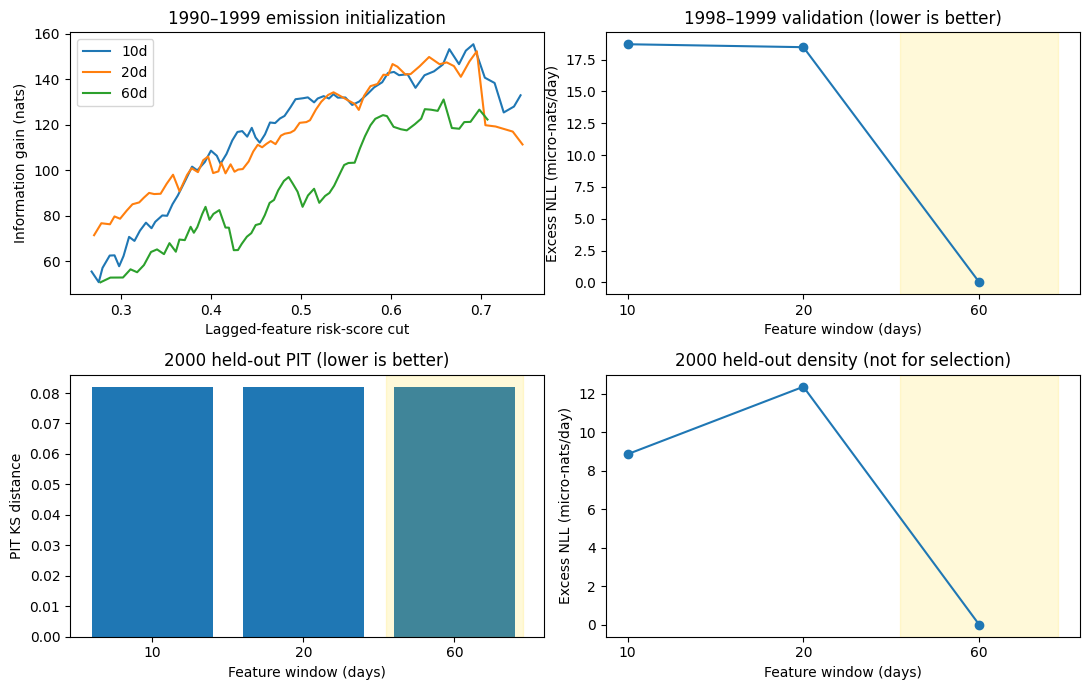

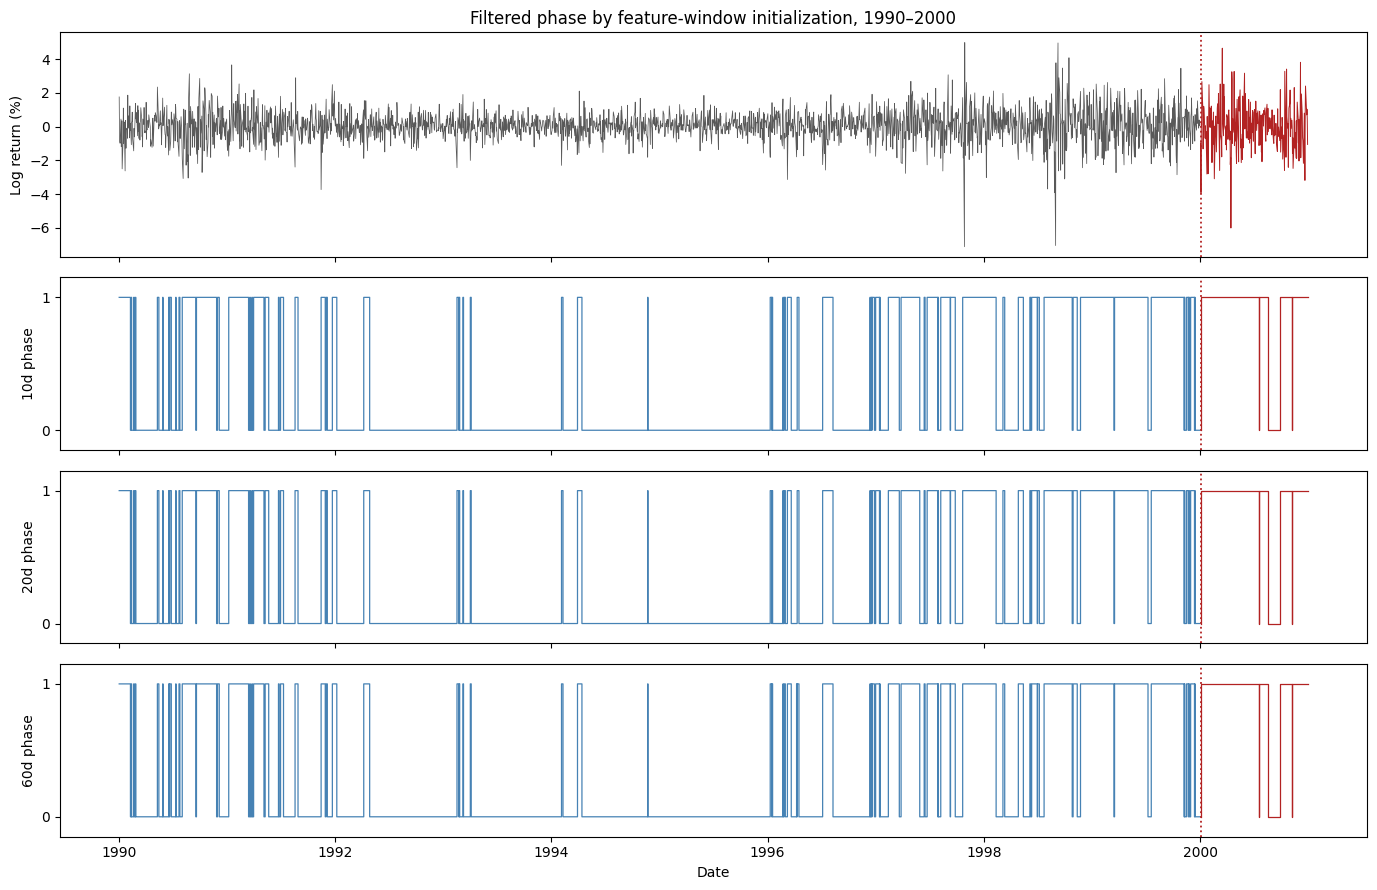

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for window in WINDOWS:
    candidate_table = final_results[window]["fit"]["initialization"]["candidates"]
    axes[0, 0].plot(candidate_table["cut"], candidate_table["gain_nats"], label=f"{window}d")
axes[0, 0].set(xlabel="Lagged-feature risk-score cut", ylabel="Information gain (nats)", title="1990–1999 emission initialization")
axes[0, 0].legend()
validation_delta = 1e6 * (validation_metrics.loc[list(WINDOWS), "validation_mean_nll"] - validation_metrics["validation_mean_nll"].min())
axes[0, 1].plot(range(len(WINDOWS)), validation_delta, marker="o")
axes[0, 1].set(xlabel="Feature window (days)", ylabel="Excess NLL (micro-nats/day)", title="1998–1999 validation (lower is better)", xticks=range(len(WINDOWS)), xticklabels=WINDOWS)
axes[1, 0].bar([str(window) for window in WINDOWS], final_metrics.loc[list(WINDOWS), "pit_ks_2000"])
axes[1, 0].set(xlabel="Feature window (days)", ylabel="PIT KS distance", title="2000 held-out PIT (lower is better)")
test_delta = 1e6 * (final_metrics.loc[list(WINDOWS), "test_mean_nll"] - final_metrics["test_mean_nll"].min())
axes[1, 1].plot(range(len(WINDOWS)), test_delta, marker="o")
axes[1, 1].set(xlabel="Feature window (days)", ylabel="Excess NLL (micro-nats/day)", title="2000 held-out density (not for selection)", xticks=range(len(WINDOWS)), xticklabels=WINDOWS)
for axis in axes.ravel()[1:]:
    axis.axvspan(WINDOWS.index(selected_window) - 0.45, WINDOWS.index(selected_window) + 0.45, color="gold", alpha=0.15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sweep_metrics.png", dpi=160)
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1, 1, 1]})
axes[0].plot(training.index, 100 * training.to_numpy(), color="0.35", linewidth=0.55)
axes[0].plot(test.index, 100 * test.to_numpy(), color="firebrick", linewidth=0.7)
axes[0].set(ylabel="Log return (%)", title="Filtered phase by feature-window initialization, 1990–2000")
for axis, window in zip(axes[1:], WINDOWS):
    result = final_results[window]
    fitted = result["fit"]
    forecast = result["forecast"]
    high_state = fitted["high_state"]
    training_phase = (np.argmax(forecast["fit_filtered"], axis=1) == high_state).astype(int)
    test_phase = (np.argmax(forecast["filtered"], axis=1) == high_state).astype(int)
    axis.step(training.index, training_phase, where="post", color="steelblue", linewidth=0.9)
    axis.step(test.index, test_phase, where="post", color="firebrick", linewidth=0.9)
    axis.set(ylabel=f"{window}d phase", ylim=(-0.15, 1.15), yticks=[0, 1])
for axis in axes:
    axis.axvline(test.index.min(), color="firebrick", linestyle=":", linewidth=1.3)
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "regime_switch_sweep.png", dpi=160)
plt.show()

## PIT and CDF for all three windows

For each held-out day, use the **pre-observation** state weights $q_{t,k}=P(S_t=k\mid r_{<t})$:

$$
F_t(x)=\sum_{k=1}^{2}q_{t,k}\Phi\!\left(\frac{x-\mu_k}{\sigma_k}\right),
\qquad u_t=F_t(r_t).
$$

The PIT histograms compare $u_t$ with a uniform reference. The CDF comparison uses the 2000 empirical return CDF and each model's **mean daily one-step predictive CDF**. The empirical curve is not used to fit the emissions. The CDF area is measured in return percentage points; these are descriptive calibration checks, not formal independent-sample tests.

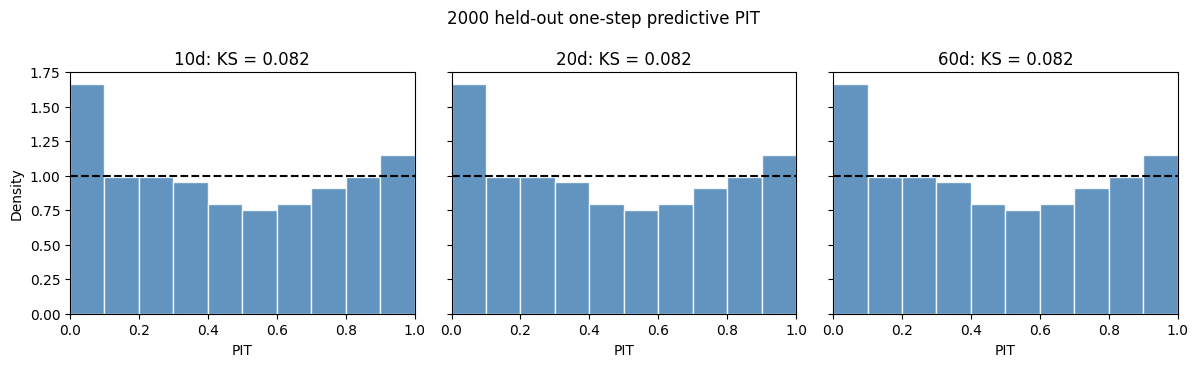

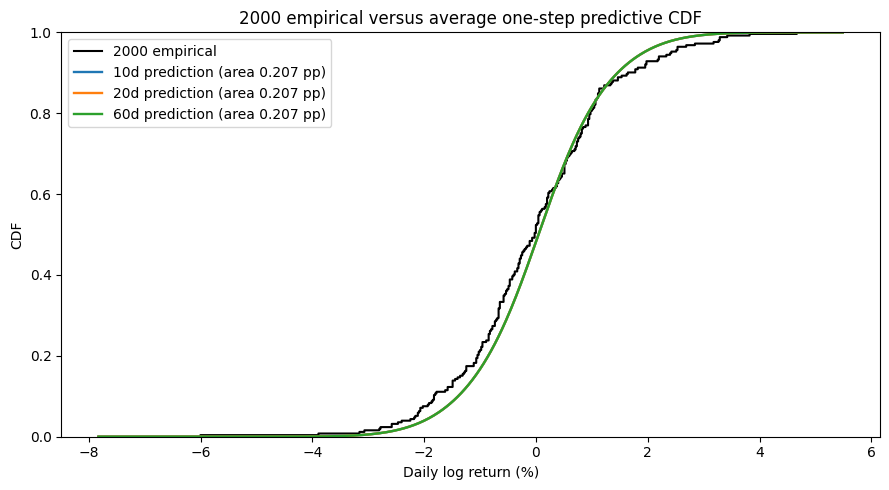

        test_mean_nll  pit_ks_2000  cdf_area_pp_2000
window                                              
10            -2.8184       0.0819            0.2072
20            -2.8184       0.0819            0.2072
60            -2.8184       0.0819            0.2072


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
for axis, window in zip(axes, WINDOWS):
    pit = final_results[window]["pit"]
    axis.hist(pit, bins=np.linspace(0, 1, 11), density=True,
              edgecolor="white", color="steelblue", alpha=0.85)
    axis.axhline(1, color="black", linestyle="--")
    axis.set(xlabel="PIT", title=f"{window}d: KS = {final_metrics.loc[window, 'pit_ks_2000']:.3f}", xlim=(0, 1))
axes[0].set_ylabel("Density")
fig.suptitle("2000 held-out one-step predictive PIT")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pit_sweep_2000.png", dpi=160)
plt.show()

grid = np.linspace(min(test.min(), training.min()) * 1.1, max(test.max(), training.max()) * 1.1, 600)
empirical_cdf = np.searchsorted(np.sort(test.to_numpy()), grid, side="right") / len(test)
fig, ax = plt.subplots(figsize=(9, 5))
ax.step(100 * grid, empirical_cdf, where="post", color="black", linewidth=1.5, label="2000 empirical")
for window in WINDOWS:
    result = final_results[window]
    means, sds = result["means"], result["sds"]
    component_cdf = 0.5 * (
        1 + np.vectorize(erf, otypes=[float])(
            (grid[:, None] - means[None, :]) / (np.sqrt(2) * sds[None, :])
        )
    )
    predictive_cdf = component_cdf @ result["forecast"]["predicted"].mean(axis=0)
    area_pp = float(100 * np.trapezoid(np.abs(empirical_cdf - predictive_cdf), grid))
    final_metrics.loc[window, "cdf_area_pp_2000"] = area_pp
    ax.plot(100 * grid, predictive_cdf, linewidth=1.7,
            label=f"{window}d prediction (area {area_pp:.3f} pp)")
ax.set(xlabel="Daily log return (%)", ylabel="CDF", title="2000 empirical versus average one-step predictive CDF", ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cdf_sweep_2000.png", dpi=160)
plt.show()
print(final_metrics[["test_mean_nll", "pit_ks_2000", "cdf_area_pp_2000"]].round(4).to_string())

## Saved artifacts and interpretation

Outputs include the sweep metrics and plots, each candidate information-gain curve, feature-derived initial groups, fitted Gaussian parameters, daily 2000 forecasts/PIT, and exact raw-order HMM probabilities. The selected window is determined **only** by 1998–1999 validation mean negative log density. The 2000 metrics are held-out descriptions, not selection criteria. A close match between windows indicates initialization sensitivity is small; it does not validate Gaussian emissions.

In [28]:
validation_metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv")
final_metrics.to_csv(OUTPUT_DIR / "final_metrics.csv")
pd.concat(candidate_tables, ignore_index=True).to_csv(OUTPUT_DIR / "cut_candidates.csv", index=False)
pd.concat(initial_group_rows, ignore_index=True).to_csv(OUTPUT_DIR / "initial_feature_groups.csv", index=False)
pd.DataFrame(parameter_rows).to_csv(OUTPUT_DIR / "emission_parameters.csv", index=False)
pd.concat(forecast_rows, ignore_index=True).to_csv(OUTPUT_DIR / "forecasts_2000.csv", index=False)
summary = {
    "instrument": "S&P 500 price index",
    "return": "daily log return",
    "windows": list(WINDOWS),
    "feature_construction": "prior-window volatility rank / 2 + reversed prior-window mean rank / 2",
    "cut_selection": "training-only grouped Gaussian likelihood gain, 15–85% score quantiles, 15% minimum group",
    "validation_fit_years": [1990, 1997],
    "validation_years": [1998, 1999],
    "final_fit_years": [1990, 1999],
    "evaluation_year": 2000,
    "selected_window_by_validation": selected_window,
    "max_iter": MAX_ITER, "tol": TOL, "min_variance": MIN_VARIANCE,
    "models": {},
}
for window in WINDOWS:
    fitted = final_results[window]["fit"]
    model = fitted["model"]
    initialization = fitted["initialization"]
    summary["models"][str(window)] = {
        "selected_score_cut": float(initialization["selected"]["cut"]),
        "center": initialization["center"], "scale": initialization["scale"],
        "start_probabilities": model.states.start.tolist(),
        "transition_matrix": model.states.transitions.tolist(),
        "fitted_means_z": model.emission.means[:, 0].tolist(),
        "fitted_variances_z": model.emission.covariances[:, 0, 0].tolist(),
        "last_training_filtered": final_results[window]["forecast"]["fit_filtered"][-1].tolist(),
        "first_test_predicted": final_results[window]["forecast"]["first_prior"].tolist(),
        "training_log_likelihood_z": float(model.history[-1]),
        "converged": bool(fitted["trainer"].converged),
        "em_updates": fitted["trainer"].n_iter,
    }
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2))
print(f"Saved sweep to {OUTPUT_DIR}")

Saved sweep to /Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/data/artifacts/sp500_two_regime/vol_mean_sweep
